# notes

description:
    Load the FPLC csv data in FPLC_data/file.csv, clean headers, parse numeric columns, and graph (UV, Conductivity, fractions, gel samples) vs mL 

requirements:
    pandas, matplotlib

# imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.weight"] = "bold"  # Bolds general text (titles, etc.)
plt.rcParams["axes.labelweight"] = "bold"  # Bolds x and y axis labels
from pathlib import Path

# file selection

In [4]:
csvfile = "20260401_ZD_TigE_recon.csv"
# print(f"Current csvfile: {csvfile}")
DATA_DIR = Path(csvfile).resolve().parent 
# print(f"Data directory: {DATA_DIR}")
CSV_FILE = DATA_DIR / csvfile
# print(f"Reading data from: {CSV_FILE}")

# read raw csv


In [5]:
# The file has 2 rows to ignore at the top 
# then one header row, then the data starts at row 4 (0-indexed row 3)
uv_cond_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\s+",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[0,1,3],  # only mL, mAU, mS/cm columns
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

injection_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\s+",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[6],  # only injection column
    nrows=1,
    engine="python",
    encoding="utf-16",
    na_values=["", '""'],
)

fractions_raw = pd.read_csv(
    CSV_FILE,
    sep=r"\s",    # whitespace sep (tabs + spaces)
    header=2,   # header row to parse
    usecols=[8,9],  # mL and fraction# 
    engine="python",
    encoding="utf-16",
    # converters={1: int},
    na_values=["", '""'],
)
fractions_raw["Fraction"] = fractions_raw["Fraction"].astype(str).str.replace(r"[^\d\-]", "", regex=True)
# print("Columns:", uv_cond_raw.columns.tolist())

# convert to numeric
uv_cond_df = uv_cond_raw.apply(pd.to_numeric, errors="coerce")
injection_df = injection_raw.apply(pd.to_numeric, errors="coerce")
fractions_df = fractions_raw.apply(pd.to_numeric, errors="coerce")

# print("sample data:")
# print(uv_cond_df.head())
# print(injection_df)
# print(fractions_raw)
# print(fractions_df.head())

# plot

## full plot

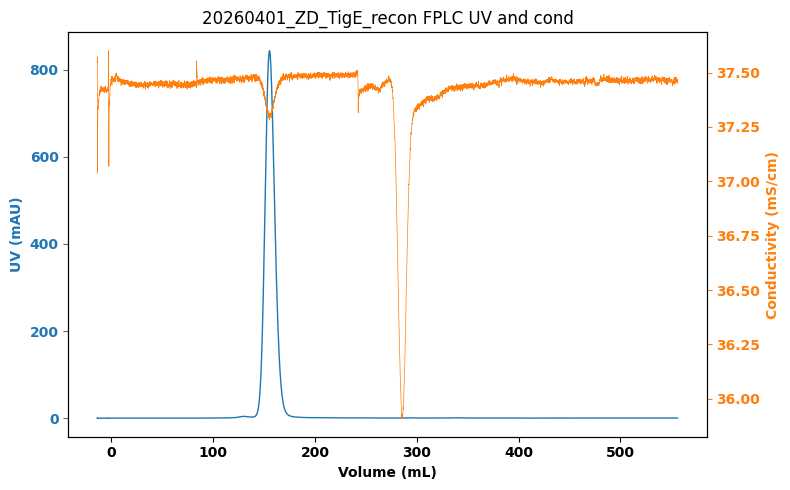

In [6]:
## set variables 
show_cond = 1  # show conductance data 

# change colors 
color_uv = "tab:blue"
color_cond = "tab:orange"

# figure size 
fig_width = 16 * 0.5 
fig_height = 10 * 0.5 

# set x and y 
x = uv_cond_df["ml"]
y_uv = uv_cond_df["mAU"]
y_cond = uv_cond_df["mS/cm"] if "mS/cm" in uv_cond_df.columns else None

fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))

# set axes 
ax1.set_xlabel("Volume (mL)")
ax1.set_ylabel("UV (mAU)", color=color_uv)

# plot uv
ax1.plot(x, y_uv, color=color_uv, linewidth=1)
ax1.tick_params(axis="y", colors=color_uv)

# plot conductance 
if show_cond:
    ax2 = ax1.twinx()
    ax2.set_ylabel("Conductivity (mS/cm)", color=color_cond)
    ax2.plot(x, y_cond, color=color_cond, linewidth=0.5, linestyle="-")
    ax2.tick_params(axis="y", colors=color_cond)

# show plot 
# title should match csv file for consistency 
plt.title(f"{csvfile[:-4]} FPLC UV{" and cond" if show_cond==1 else ""}")

# ax1.grid(True, axis="x", alpha=0.3)  # gridlines 
fig.tight_layout()

# save png file, png name matches csv and title 
out_png = DATA_DIR / f"{csvfile[:-4]}_FPLC_UV{"_and_cond" if show_cond==1 else ""}"
fig.savefig(out_png, dpi=1500)

plt.show()

## zoomed plot

In [7]:
## set variables 
show_cond = 1  # show conductance data 

show_frac = 1  # show fractions 
highlight_frac = 1  # highlight pooled fractions 
frac_first = 34
frac_last = 42

gel_samples = []  # highlight gel samples (leave empty if not)

# plot axes bounds 
ml_start = 110 
ml_end = 190
mAU_height = 1000

# change colors 
color_uv = "tab:blue"
color_cond = "tab:orange"
color_frac = "tab:green"
color_gel = "xkcd:mustard yellow"

# figure size 
fig_width = 16 * 0.5 
fig_height = 10 * 0.5 

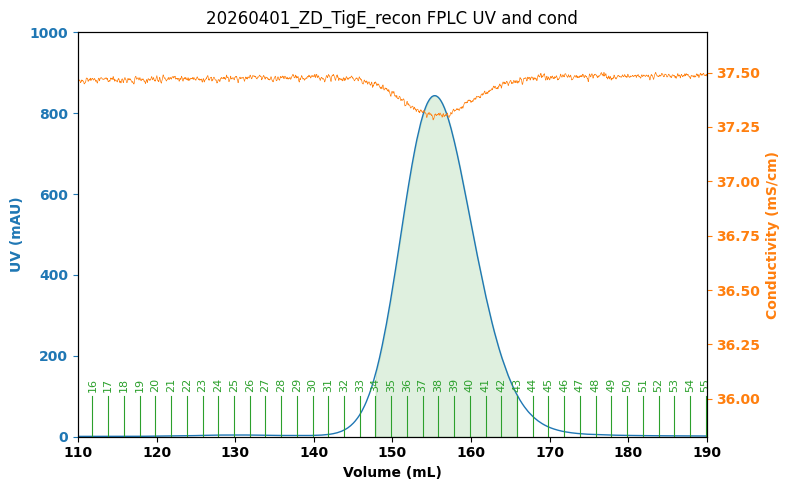

In [8]:
## plot

# set x and y 
x = uv_cond_df["ml"]
y_uv = uv_cond_df["mAU"]
y_cond = uv_cond_df["mS/cm"] if "mS/cm" in uv_cond_df.columns else None

# make plot 
fig, ax1 = plt.subplots(figsize=(fig_width, fig_height))

# set axes 
ax1.set_xlabel("Volume (mL)")
ax1.set_ylabel("UV (mAU)", color=color_uv)
ax1.set_xlim(ml_start, ml_end)
ax1.set_ylim(0, mAU_height)

# plot uv
ax1.plot(x, y_uv, color=color_uv, linewidth=1)
ax1.tick_params(axis="y", colors=color_uv)

# plot conductance 
if show_cond:
    ax2 = ax1.twinx()
    ax2.set_ylabel("Conductivity (mS/cm)", color=color_cond)
    ax2.plot(x, y_cond, color=color_cond, linewidth=0.5, linestyle="-")
    ax2.tick_params(axis="y", colors=color_cond)

# plot fractions 
if show_frac:
    # plot fraction lines and text labels 
    for i, (ml, frac) in enumerate(zip(fractions_df["ml.4"], fractions_df["Fraction"]), start=1):
        if ml > ml_start and ml < ml_end:
            ax1.axvline(x=ml, color=color_frac, linestyle="-", linewidth=0.8, ymin=0, ymax=0.1)
            ax1.text(ml, ax1.get_ylim()[1]*0.11, f"{frac:.0f}", rotation=90,
                    va="bottom", ha="center", fontsize=8, color=color_frac, fontweight='normal')

    # shade the selected fraction range (frac_first..frac_last) under UV curve
    if highlight_frac:
        x_min = fractions_df.loc[fractions_df["Fraction"] == frac_first, "ml.4"].iloc[0]
        x_max = fractions_df.loc[fractions_df["Fraction"] == frac_last+1, "ml.4"].iloc[0]
        mask = (x >= x_min) & (x <= x_max)
        ax1.fill_between(x[mask], y_uv[mask], color=color_frac, alpha=0.15)

# plot gel samples 
if len(gel_samples)>0:
    for gel_frac in gel_samples:
        x_min = fractions_df.loc[fractions_df["Fraction"] == gel_frac, "ml.4"].iloc[0]
        x_max = fractions_df.loc[fractions_df["Fraction"] == gel_frac+1, "ml.4"].iloc[0]
        mask = (x >= x_min) & (x <= x_max)
        ax1.fill_between(x[mask], y_uv[mask], color=color_gel, alpha=0.25)

# show plot 
# title should match csv file for consistency 
plt.title(f"{csvfile[:-4]} FPLC UV{" and cond" if show_cond==1 else ""}")

# ax1.grid(True, axis="x", alpha=0.3) # gridlines 
fig.tight_layout()

# save png file, png name matches csv and title 
out_png = DATA_DIR / f"{csvfile[:-4]}_FPLC_UV{"_and_cond" if show_cond==1 else ""}_zoomed"
fig.savefig(out_png, dpi=1500)

plt.show()